Found 5494 files belonging to 12 classes.
Using 4396 files for training.
Found 5494 files belonging to 12 classes.
Using 1098 files for validation.
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 8s 0us/step
Epoch 1/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 114s 801ms/step - accuracy: 0.5397 - loss: 1.4512 - val_accuracy: 0.8880 - val_loss: 0.4155
Epoch 2/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 106s 768ms/step - accuracy: 0.8324 - loss: 0.5326 - val_accuracy: 0.8907 - val_loss: 0.3723
Epoch 3/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 102s 738ms/step - accuracy: 0.8581 - loss: 0.4289 - val_accuracy: 0.9016 - val_loss: 0.3327
Epoch 4/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 102s 741ms/step - accuracy: 0.8857 - loss: 0.3414 - val_accuracy: 0.9071 - val_loss: 0.3419
Epoch 5/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 104s 757ms/step - accuracy: 0.9128 - loss: 0.2585 - val_accuracy: 0.8998 - val_loss: 0.3420
Epoch 6/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 103s 744ms/step - accuracy: 0.9128 - loss: 0.2484 - val_accuracy: 0.9007 - val_loss: 0.3479
Epoch 7/1

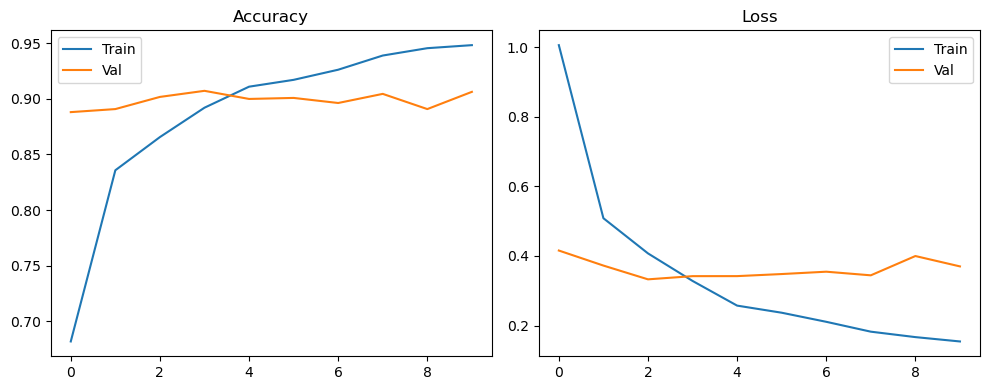

In [1]:
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import os

# Set path
dataset_dir = r"D:\Ed\DL\Proj\pest" # CHANGE THIS
img_size = (224, 224)
batch_size = 32
epochs = 10  # Quick training

# Load dataset
train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=img_size,
    batch_size=batch_size
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=img_size,
    batch_size=batch_size
)

class_names = train_ds.class_names
num_classes = len(class_names)

# Prefetch for performance
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

# Preprocess input
preprocess_input = tf.keras.applications.resnet.preprocess_input

# Build model
base_model = ResNet50(include_top=False, weights='imagenet', input_shape=img_size + (3,))
base_model.trainable = False

inputs = layers.Input(shape=img_size + (3,))
x = preprocess_input(inputs)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(num_classes, activation='softmax')(x)

model = tf.keras.Model(inputs, outputs)

# Compile and train
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history = model.fit(train_ds, validation_data=val_ds, epochs=epochs)

# Save model
model.save("resnet50_pest_classifier.h5")

# Plot
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Train")
plt.plot(history.history["val_accuracy"], label="Val")
plt.title("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Train")
plt.plot(history.history["val_loss"], label="Val")
plt.title("Loss")
plt.legend()
plt.tight_layout()
plt.savefig("resnet50_training_plot.png")
plt.show()
